# CS620 Project Abstract

**Topic:** Airfare Pricing Trends & Demand Analysis  



## Team Members
- Necey Kpakio  
  - email: nkpak001@odu.edu
  - portfolio: https://nkpak001.github.io/


## Raw Data
**URL:** https://www.transtats.bts.gov/averagefare/

**Description:**  
This dataset contains average domestic airline itinerary fares by origin city and time period. It can be used to study airfare pricing trends and compare pricing patterns across locations and quarters.


## Sample  


Airport Code: LAX | City: Los Angeles, CA | Avg Fare: $401.39 | Passenger Rank: 1  

Airport Code: ORD | City: Chicago, IL | Avg Fare: $347.85 | Passenger Rank: 2  

Airport Code: DEN | City: Denver, CO | Avg Fare: $341.94 | Passenger Rank: 3  

Airport Code: ATL | City: Atlanta, GA | Avg Fare: $410.82 | Passenger Rank: 4  

Airport Code: BOS | City: Boston, MA | Avg Fare: $355.81 | Passenger Rank: 5   

## End Goal
The goal is to identify patterns that explain which locations have more expensive flights and better understand airfare pricing differences across cities. The project will look at how factors like time of year, location, and passenger volume influence airfare costs.

## Secondary Data Sets
**US Census Data**  
**URL:** https://www.census.gov/data.html  

**Purpose:**  
This dataset can be used to incorporate population and income data to better understand how regional demand and economic factors may influence airfare pricing.


## Project Plan

- Week 1: Project Planning – get familiar with the dataset and understand the variables.  
- Week 2: Data Collection – gather and load the dataset into the environment.  
- Week 3: Data Cleaning – fix missing values and organize the data.  
- Week 4: Exploratory Analysis – look for patterns in airfare pricing.  
- Week 5: Visualizations – create charts to show trends and demand.  
- Week 6: Final Report – summarize findings and complete the project.


In [ ]:
import pandas as pd
import plotly.express as px

# Project timeline
df = pd.DataFrame([
    dict(Task="Project Planning", Start="2026-03-30", Finish="2026-04-03", Resource="Necey"),
    dict(Task="Data Collection", Start="2026-04-04", Finish="2026-04-10", Resource="Necey"),
    dict(Task="Data Cleaning", Start="2026-04-11", Finish="2026-04-17", Resource="Necey"),
    dict(Task="Exploratory Analysis", Start="2026-04-18", Finish="2026-04-24", Resource="Necey"),
    dict(Task="Visualizations", Start="2026-04-25", Finish="2026-05-01", Resource="Necey"),
    dict(Task="Final Report", Start="2026-05-02", Finish="2026-05-08", Resource="Necey")
])

# Create Gantt chart
fig = px.timeline(
    df,
    x_start="Start",
    x_end="Finish",
    y="Task",
    color="Resource",
    title="Project Gantt Chart"
)

fig.update_yaxes(autorange="reversed")
fig.show()

**Design Decisions**

For this project, I decided to focus on analyzing airfare pricing trends using real-world datasets instead of building a complex system. The design is centered on data analysis and visualization. At this stage, initial analysis and visualizations have been created to better understand pricing patterns across time and locations.

**Target Audience**

The target users for this project are:

*   Travelers who want to understand when flights are cheaper
*   Individuals interested in saving money on airfare
*   Students learning data analysis concepts


**Tools and Technologies**

*   Python
*   Pandas
*   Google colab
*   Matplotlib
*   Seaborn
*   Plotly






These tools were selected because they are widely used in data analytics and allow for efficient data processing and visualization.

**Data Model**

The dataset includes:


*   Airport or city information
*   Average airfare prices
*   Time (monthly or yearly data)
*   Passenger volume (if available)

This structure supports analyzing trends and comparing prices across different locations and time periods.

**System Design / Architecture**

The project follows a simple workflow:

1.   Load the dataset
2.   Clean and preprocess the data
3.   Analyze trends
4.   Create visualizations


This step-by-step approach makes the analysis easy to follow and understand.

**Core Features**


*   Identify airfare pricing trends over time
*   Compare prices between different routes
*   Analyze how demand impacts pricing
*   Visualize results using graphs


**How Design Meets User Needs**

This project helps users understand:


*   When airfare prices tend to increase or decrease
*   Which routes are more expensive
*   How pricing changes over time


The use of visualizations makes the results easier to interpret and apply.



**Data Analysis and Visualizations**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load CSV and skip title rows
df = pd.read_csv("AverageFare_Q4_2025.csv", skiprows=3)

# keep only the useful columns
df = df.iloc[:, 0:7]

# rename columns
df.columns = [
    "Rank",
    "Airport Code",
    "Airport Name",
    "City",
    "State",
    "Average Fare",
    "Adjusted Fare"
]

# clean Average Fare column
df["Average Fare"] = df["Average Fare"].replace(",", "", regex=True)
df["Average Fare"] = pd.to_numeric(df["Average Fare"], errors="coerce")

# remove empty rows
df = df.dropna(subset=["Average Fare"])

print(df.head())
print(df.columns)

  Rank Airport Code                              Airport Name        City  \
0    3          DEN                      Denver International      Denver   
1    4          ATL  Hartsfield-Jackson Atlanta International     Atlanta   
2    5          BOS                       Logan International      Boston   
3    6          EWR              Newark Liberty International      Newark   
4    7          DFW           Dallas/Fort Worth International  Dallas-DFW   

  State  Average Fare  Adjusted Fare  
0    CO        377.15         377.15  
1    GA        440.43         440.43  
2    MA        404.65         404.65  
3    NJ        449.37         449.37  
4    TX        434.46         434.46  
Index(['Rank', 'Airport Code', 'Airport Name', 'City', 'State', 'Average Fare',
       'Adjusted Fare'],
      dtype='object')


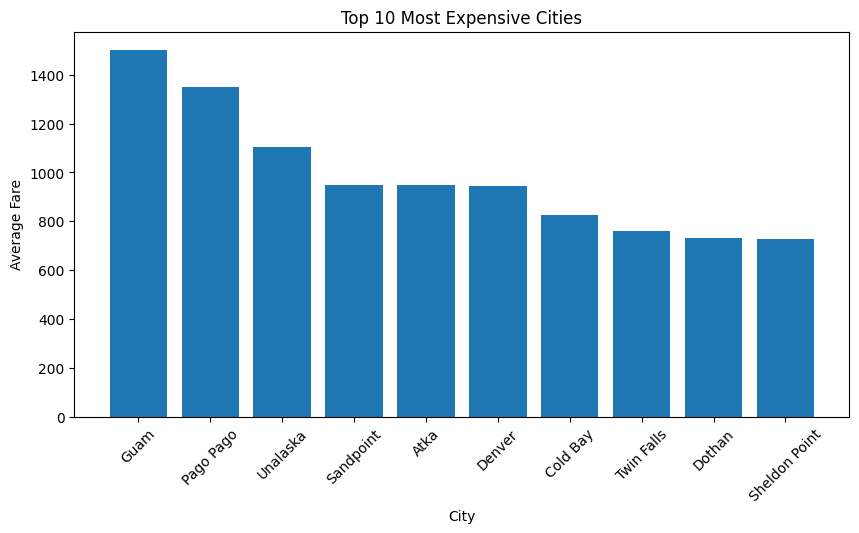

In [ ]:
#Visualization 1 – Top 10 Most Expensive Cities

top_cities = df.sort_values(by="Average Fare", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cities["City"], top_cities["Average Fare"])

plt.title("Top 10 Most Expensive Cities")
plt.xlabel("City")
plt.ylabel("Average Fare")
plt.xticks(rotation=45)

plt.show()

This chart shows the cities with the highest average airfare prices in the dataset. Some cities consistently had more expensive airfare prices than others.

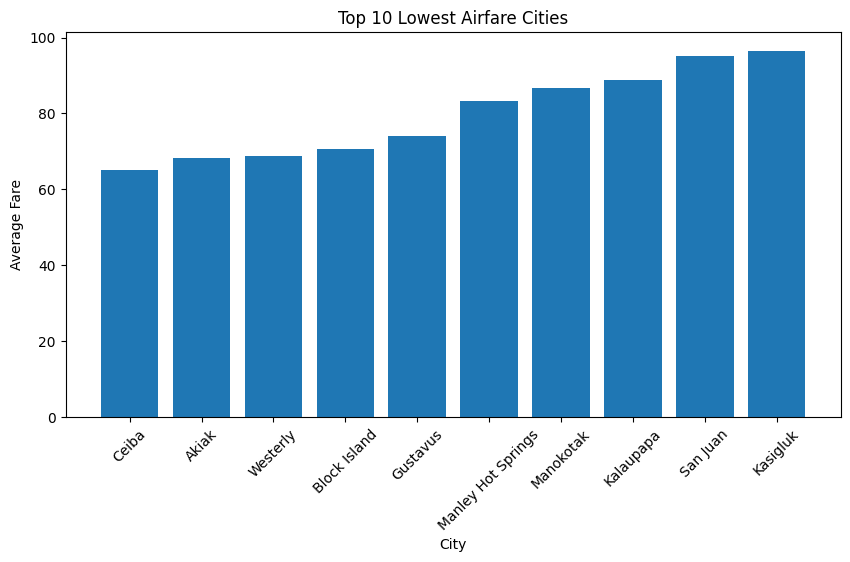

In [ ]:
#Visualization 2 – Lowest Airfare Cities

low_cities = df.sort_values(by="Average Fare").head(10)

plt.figure(figsize=(10,5))
plt.bar(low_cities["City"], low_cities["Average Fare"])

plt.title("Top 10 Lowest Airfare Cities")
plt.xlabel("City")
plt.ylabel("Average Fare")
plt.xticks(rotation=45)

plt.show()

This chart shows the cities with the lowest airfare prices in the dataset. These locations had more affordable average airfare prices compared to others.

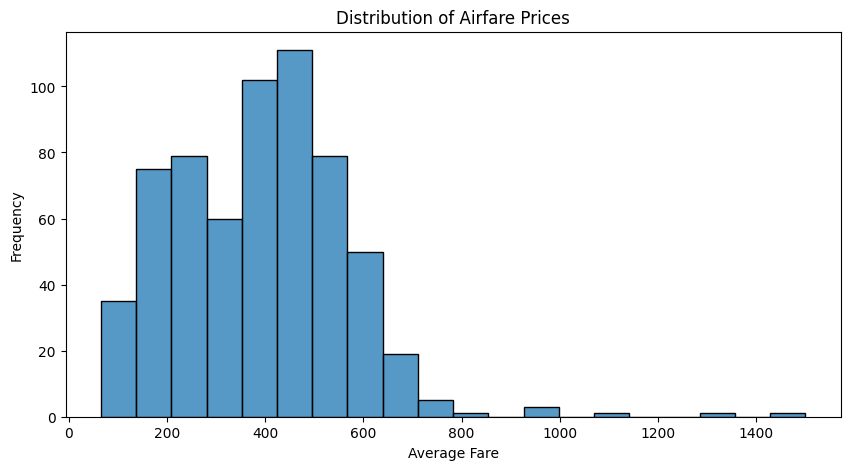

In [ ]:
#Visualization 3 – Distribution of Airfare Prices

import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df["Average Fare"], bins=20)

plt.title("Distribution of Airfare Prices")
plt.xlabel("Average Fare")
plt.ylabel("Frequency")

plt.show()

This histogram shows the overall distribution of airfare prices throughout the dataset. Most airfare prices fall within a certain range, while fewer cities had extremely high airfare prices.

**Results and Findings**

The visualizations showed that airfare prices varied across different cities and locations. Some locations consistently had higher airfare prices, while others were more affordable.

The charts made it easier to identify patterns and compare airfare prices across different periods and locations.

**Current Status**


*   Dataset selected (BTS airfare dataset)
*   Data loaded into Colab
*   Data cleaning completed
*   Initial analysis performed
*   Gantt chart created
*   Final visualizations completed




**What is Left To Do**


*   Finalize presentation recording
*   Complete final review of report


**Summary**

This project analyzed airfare pricing trends using real-world BTS airfare data. Through data cleaning, analysis, and visualization, patterns were identified showing how airfare prices change over time and across different locations.

The visualizations helped simplify large amounts of data and made trends easier to understand. This project also demonstrated the importance of preprocessing and visualization when working with real-world datasets.

**Conclusion**

This project demonstrated how data analysis and visualization can be used to better understand airfare pricing trends using real-world datasets.

The project also reinforced the importance of data cleaning, preprocessing, and visualization when working with large datasets.

Future work could include machine learning techniques to predict future airfare prices. This project also helped strengthen my interest in pursuing a career in data analytics.

**Project Presentation Video**

YouTube Link: https://youtu.be/I08dluEpudA

**References**

BTS Average Fare Data:
https://www.transtats.bts.gov/averagefare/

US Census Data:
https://www.census.gov/data.html